<a href="https://colab.research.google.com/github/Mayra-25/TelecomX-Latam/blob/main/TelecomX_LATAM_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis

# Configuración estética
sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

#📌 Extracción

In [9]:
# 1. Cargar el archivo JSON
with open('TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

# 2. Aplanar los datos (Flattening)
# Esto convierte campos como "customer.gender" en columnas individuales
df = pd.json_normalize(datos_crudos)

# 3. Mostrar información básica de la carga
print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Datos cargados: 7267 filas y 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4


#🔧 Transformación

In [10]:
# 1. Limpiar los nombres de las columnas (quitar prefijos como 'account.' o 'customer.')
# Esto facilita el trabajo según tu diccionario de datos
df.columns = [col.split('.')[-1] for col in df.columns]

# 2. Transformar 'Total' a numérico
# Es crítico porque en el JSON original el total viene como string ("1873.7")
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# 3. Manejo de valores nulos
# Si hay clientes nuevos (tenure = 0), el Total suele ser nulo. Los llenamos con 0.
df['Total'] = df['Total'].fillna(0)

# 4. Limpieza de strings
# Asegurar que no haya espacios en blanco extras en las columnas de texto
columnas_objeto = df.select_dtypes(include=['object']).columns
df[columnas_objeto] = df[columnas_objeto].apply(lambda x: x.str.strip())

# 5. Verificación de tipos de datos final
print("Tipos de datos después de la transformación:")
print(df.dtypes[['customerID', 'tenure', 'Monthly', 'Total', 'Churn']])

Tipos de datos después de la transformación:
customerID     object
tenure          int64
Monthly       float64
Total         float64
Churn          object
dtype: object


#📊 Carga y análisis

=== MEDIDAS ESTADÍSTICAS GENERALES ===


,mean,median,std,min,max,skewness,kurtosis
tenure,32.35,29.00,24.57,0.00,72.00,0.24,-1.39
Monthly,64.72,70.30,30.13,18.25,118.75,-0.22,-1.26
Total,"2,277.18","1,389.20","2,268.65",0.00,"8,684.80",0.97,-0.23



=== COMPORTAMIENTO POR ESTADO DE CHURN (PROMEDIOS) ===


tenure              Monthly                 Total                  
        mean median   std    mean median   std     mean   median      std
Churn                                                                    
       31.57  29.00 25.00   63.41  69.10 31.39 2,196.93 1,163.17 2,329.96
No     37.57  38.00 24.11   61.27  64.43 31.09 2,549.91 1,679.53 2,329.95
Yes    17.98  10.00 19.53   74.44  79.65 24.67 1,531.80   703.55 1,890.82

/tmp/ipykernel_230/3756137688.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Monthly', palette='Set2')


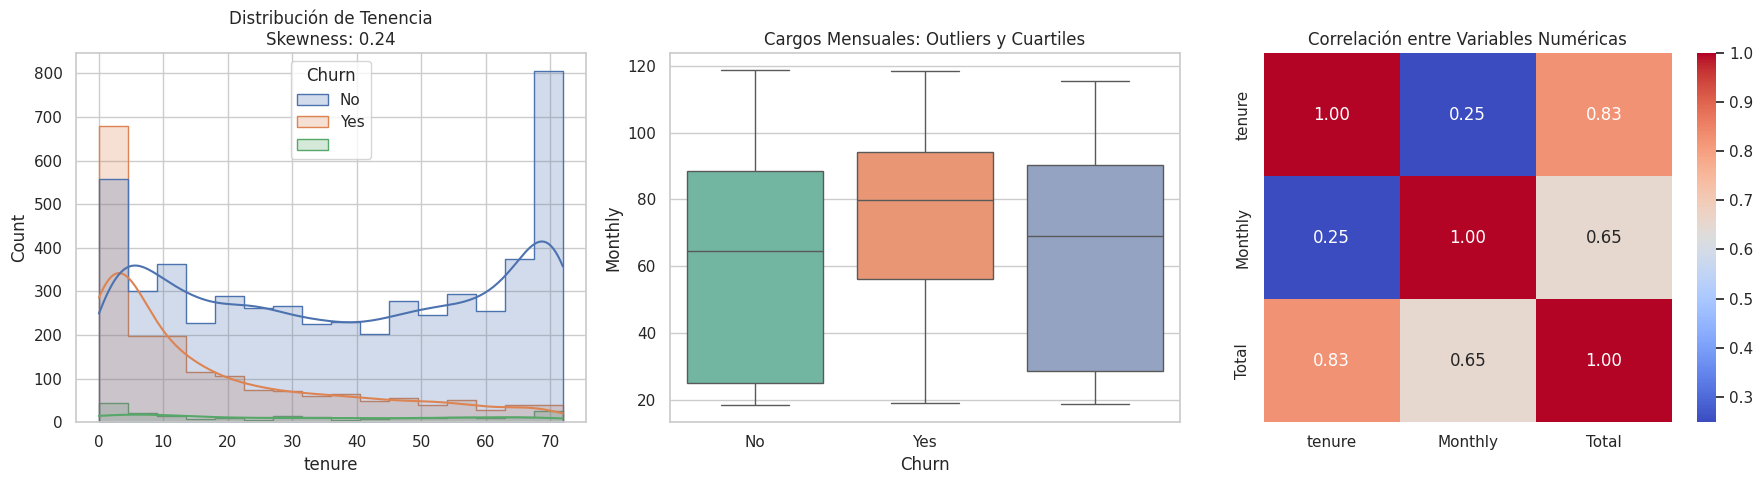


💡 Hallazgo rápido:
Los clientes que abandonan pagan en promedio $74.44, mientras que los que se quedan pagan $61.27.


In [11]:
# --- CARGA ---
df.to_csv('TelecomX_Procesado.csv', index=False)

# --- ANÁLISIS ESTADÍSTICO ---

# 1. Medidas de Tendencia Central y Dispersión General
columnas_num = ['tenure', 'Monthly', 'Total']
estadisticos_gral = df[columnas_num].describe().T

# Agregar Mediana (50% ya está en describe, pero lo explicitamos), Asimetría y Curtosis
estadisticos_gral['median'] = df[columnas_num].median()
estadisticos_gral['skewness'] = df[columnas_num].skew()   # > 0: cola a la derecha
estadisticos_gral['kurtosis'] = df[columnas_num].kurt()   # > 0: más picuda que la normal

print("=== MEDIDAS ESTADÍSTICAS GENERALES ===")
display(estadisticos_gral[['mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis']])

# 2. Comparación de Comportamiento: ¿Cómo varían los promedios entre clientes que se van (Churn) y los que no?
print("\n=== COMPORTAMIENTO POR ESTADO DE CHURN (PROMEDIOS) ===")
comparativa_churn = df.groupby('Churn')[columnas_num].agg(['mean', 'median', 'std'])
display(comparativa_churn)

# --- VISUALIZACIONES DE DISTRIBUCIÓN ---

plt.figure(figsize=(18, 5))

# Visualizar Distribución de Tenure (Antigüedad)
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element="step")
plt.title(f'Distribución de Tenencia\nSkewness: {df["tenure"].skew():.2f}')

# Visualizar Distribución de Cargos Mensuales
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Churn', y='Monthly', palette='Set2')
plt.title('Cargos Mensuales: Outliers y Cuartiles')

# Visualizar Correlación (Para ver relación entre variables)
plt.subplot(1, 3, 3)
sns.heatmap(df[columnas_num].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Numéricas')

plt.tight_layout()
plt.show()

# Conclusión rápida basada en los datos
print("\n💡 Hallazgo rápido:")
media_churn = df[df['Churn'] == 'Yes']['Monthly'].mean()
media_no_churn = df[df['Churn'] == 'No']['Monthly'].mean()
print(f"Los clientes que abandonan pagan en promedio ${media_churn:.2f}, "
      f"mientras que los que se quedan pagan ${media_no_churn:.2f}.")

In [12]:

df.to_csv("datos_tratados.csv", index=False)

=== TASA DE ABANDONO (CHURN RATE) POR CATEGORÍA ===

--- Análisis por gender ---


Churn,,No,Yes
gender,,,
Female,2.90,70.96,26.14
Male,3.27,71.43,25.31


------------------------------
--- Análisis por SeniorCitizen ---


Churn,,No,Yes
SeniorCitizen,,,
1,3.38,56.35,40.27
0,3.02,74.08,22.89


------------------------------
--- Análisis por Partner ---


...

------------------------------
--- Análisis por InternetService ---


Churn,,No,Yes
InternetService,,,
Fiber optic,3.19,56.25,40.56
DSL,2.69,78.86,18.45
No,3.48,89.37,7.15


------------------------------
--- Análisis por OnlineSecurity ---


Churn,,No,Yes
OnlineSecurity,,,
No,3.05,56.46,40.49
Yes,2.84,82.96,14.20
No internet service,3.48,89.37,7.15


------------------------------


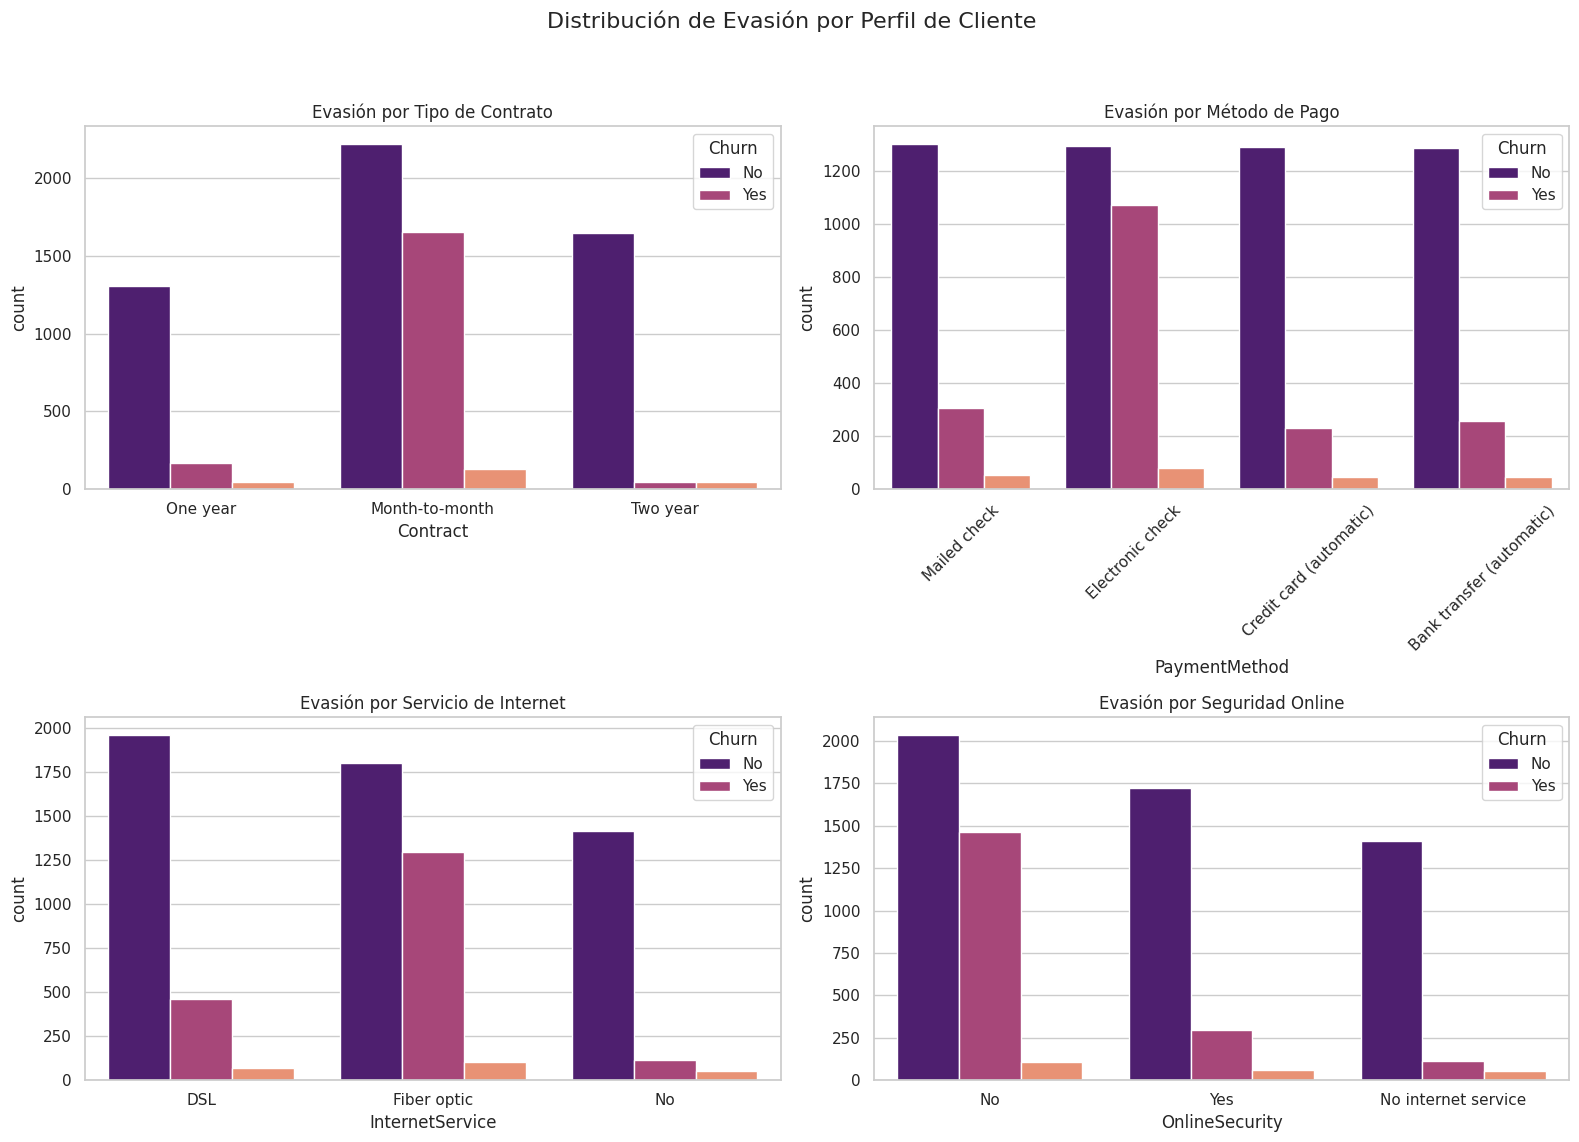

💡 Hallazgo Estratégico: El grupo con mayor tendencia a cancelar son aquellos con contrato: 'Month-to-month'.


In [13]:
# --- ANÁLISIS POR VARIABLES CATEGÓRICAS ---

# Definimos las variables que queremos explorar según el diccionario
variables_interes = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                     'Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity']

print("=== TASA DE ABANDONO (CHURN RATE) POR CATEGORÍA ===\n")

for var in variables_interes:
    # 1. Crear tabla de frecuencias: Cuenta cuántos 'Yes' y 'No' hay por categoría
    tabla_frecuencia = pd.crosstab(df[var], df['Churn'])

    # 2. Calcular el % de Churn dentro de cada categoría
    # (Casos 'Yes' / Total de la categoría) * 100
    tabla_porcentaje = pd.crosstab(df[var], df['Churn'], normalize='index') * 100

    print(f"--- Análisis por {var} ---")
    display(tabla_porcentaje.sort_values(by='Yes', ascending=False)) # Ordenar de mayor a menor riesgo
    print("-" * 30)

# --- VISUALIZACIÓN ESTRATÉGICA ---

# Vamos a graficar las 4 variables con mayor impacto visual para el negocio
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Distribución de Evasión por Perfil de Cliente', fontsize=16)

# 1. Por Tipo de Contrato (Clave para la retención)
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0,0], palette='magma')
axes[0,0].set_title('Evasión por Tipo de Contrato')

# 2. Por Método de Pago
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0,1], palette='magma')
axes[0,1].set_title('Evasión por Método de Pago')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Por Servicio de Internet
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1,0], palette='magma')
axes[1,0].set_title('Evasión por Servicio de Internet')

# 4. Por Seguridad en Línea
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', ax=axes[1,1], palette='magma')
axes[1,1].set_title('Evasión por Seguridad Online')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- CONCLUSIÓN AUTOMATIZADA ---
max_churn_contract = (pd.crosstab(df['Contract'], df['Churn'], normalize='index')['Yes'].idxmax())
print(f"💡 Hallazgo Estratégico: El grupo con mayor tendencia a cancelar son aquellos con contrato: '{max_churn_contract}'.")

=== ESTADÍSTICAS DESCRIPTIVAS SEGÚN EVASIÓN (CHURN) ===


tenure              Monthly                 Total                  
        mean median   std    mean median   std     mean   median      std
Churn                                                                    
       31.57  29.00 25.00   63.41  69.10 31.39 2,196.93 1,163.17 2,329.96
No     37.57  38.00 24.11   61.27  64.43 31.09 2,549.91 1,679.53 2,329.95
Yes    17.98  10.00 19.53   74.44  79.65 24.67 1,531.80   703.55 1,890.82

/tmp/ipykernel_230/1735890701.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Monthly', palette='husl')
/tmp/ipykernel_230/1735890701.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y='Total', palette='husl', split=True)


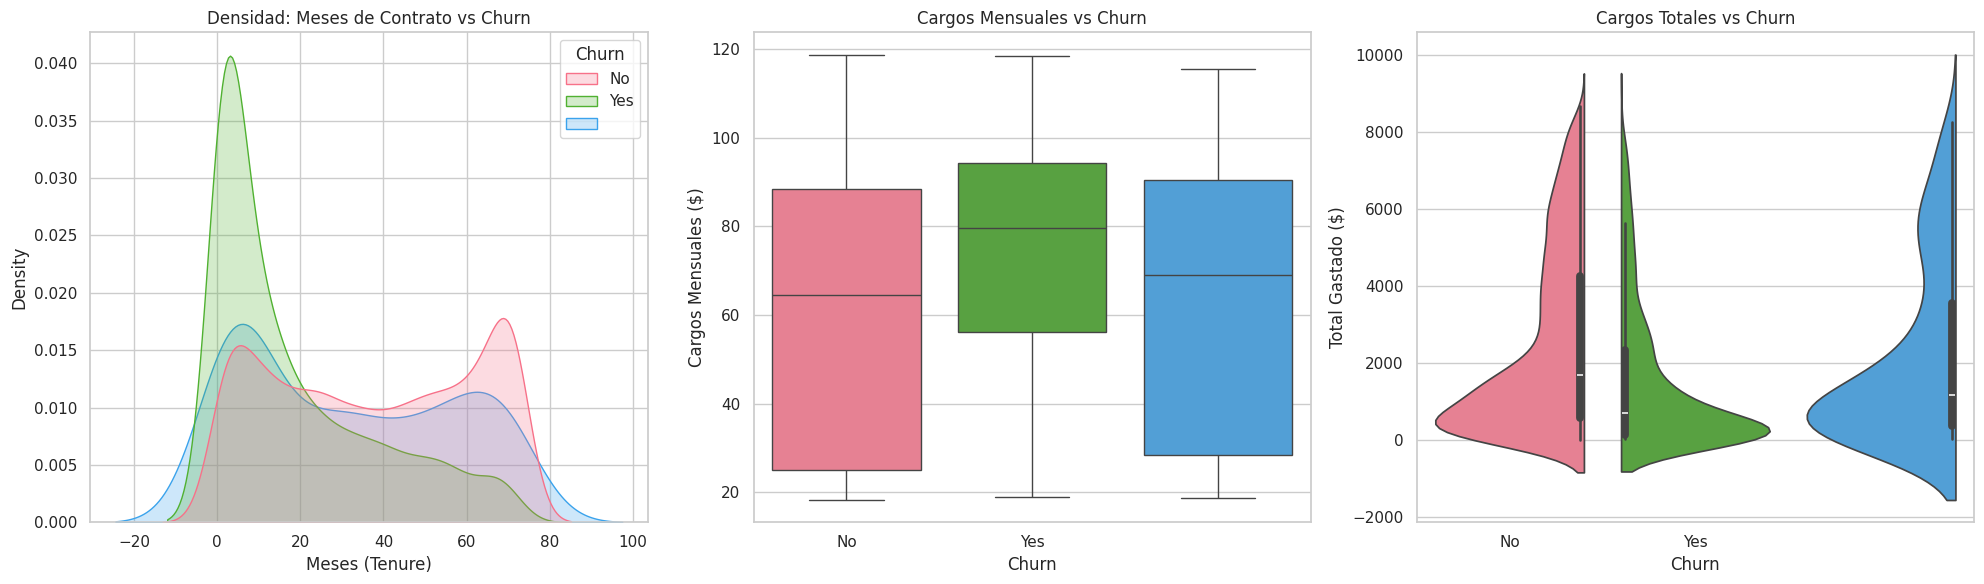


=== CONTEO DE EVASIÓN POR RANGO DE ANTIGÜEDAD ===


Churn,,No,Yes
tenure_range,,,
0-1 año,3.50,50.49,46.01
1-2 años,2.01,69.86,28.13
2-4 años,3.28,77.00,19.72
4-6 años,3.03,87.74,9.22


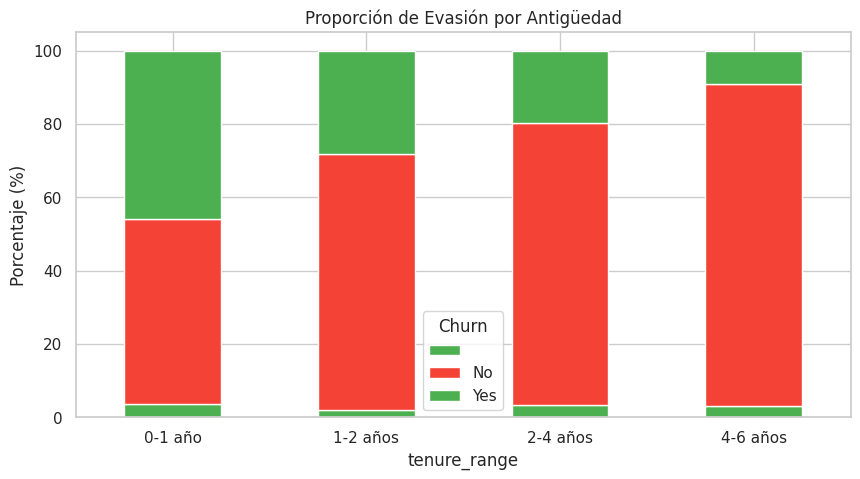

In [14]:
# --- ANÁLISIS DE DISTRIBUCIÓN NUMÉRICA ---

print("=== ESTADÍSTICAS DESCRIPTIVAS SEGÚN EVASIÓN (CHURN) ===")
# Comparamos la media y la mediana de las variables clave para los dos grupos
stats_por_churn = df.groupby('Churn')[['tenure', 'Monthly', 'Total']].agg(['mean', 'median', 'std'])
display(stats_por_churn)

# --- VISUALIZACIÓN DE COMPORTAMIENTO ---

plt.figure(figsize=(20, 6))

# 1. Distribución de Tenencia (¿Cuándo se van?)
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='husl')
plt.title('Densidad: Meses de Contrato vs Churn')
plt.xlabel('Meses (Tenure)')

# 2. Distribución de Cargos Mensuales (¿El precio influye?)
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Churn', y='Monthly', palette='husl')
plt.title('Cargos Mensuales vs Churn')
plt.ylabel('Cargos Mensuales ($)')

# 3. Distribución de Cargos Totales
plt.subplot(1, 3, 3)
sns.violinplot(data=df, x='Churn', y='Total', palette='husl', split=True)
plt.title('Cargos Totales vs Churn')
plt.ylabel('Total Gastado ($)')

plt.tight_layout()
plt.show()

# --- ANÁLISIS POR RANGOS (BINNING) ---
# Creamos rangos de antigüedad para entender mejor el "conteo" de evasión
df['tenure_range'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-1 año', '1-2 años', '2-4 años', '4-6 años'])

print("\n=== CONTEO DE EVASIÓN POR RANGO DE ANTIGÜEDAD ===")
tenure_churn = pd.crosstab(df['tenure_range'], df['Churn'], normalize='index') * 100
display(tenure_churn)

# Gráfico de barras para los rangos
tenure_churn.plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'], figsize=(10,5))
plt.title('Proporción de Evasión por Antigüedad')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.show()

# 📄 Informe Final del Análisis de Datos TelecomX

Este informe presenta un resumen de los hallazgos clave obtenidos del análisis del dataset de clientes de TelecomX, con un enfoque en la tasa de abandono (Churn) y los factores que la influyen.

## 1. Resumen de la Extracción y Transformación de Datos

Se cargó el archivo `TelecomX_Data.json`, que inicialmente contenía datos anidados. Este se aplanó en un DataFrame de pandas con **7267 filas y 21 columnas**.

Los pasos clave de transformación incluyeron:
- **Limpieza de Nombres de Columnas**: Se eliminaron los prefijos `customer.`, `account.`, etc., para facilitar la manipulación de datos.
- **Conversión de Tipo de Datos**: La columna `Total` (cargos totales) se convirtió a tipo numérico, manejando correctamente los valores no válidos al convertir a `NaN` y luego imputándolos con `0` para clientes con `tenure = 0` (nuevos clientes sin cargos).
- **Manejo de Nulos**: Se imputaron los valores nulos en `Total` con 0, asumiendo que los clientes con `tenure = 0` no han acumulado cargos totales aún.
- **Limpieza de Strings**: Se eliminaron espacios en blanco adicionales de las columnas de tipo 'object' para garantizar la consistencia.

## 2. Análisis de Datos Clave

### a. Resumen de Cargos Financieros y Antigüedad

| Característica | Conteo | Media | Desviación Estándar | Mínimo | 25% Cuartil | Mediana | 75% Cuartil | Máximo |
|:---------------|-------:|------:|--------------------:|-------:|------------:|--------:|------------:|-------:|
| **Monthly**    | 7267   | 64.72 | 30.13               | 18.25  | 35.42       | 70.30   | 89.88       | 118.75 |
| **Total**      | 7267   | 2277.18| 2268.65             | 0.00   | 396.20      | 1389.20 | 3778.52     | 8684.80|
| **Tenure**     | 7267   | 32.35 | 24.57               | 0.00   | 9.00        | 29.00   | 55.00       | 72.00  |

- Los cargos mensuales (`Monthly`) varían significativamente, indicando diferentes planes de servicio.
- Los cargos totales (`Total`) también muestran una amplia dispersión, como era de esperar, influenciados por la antigüedad y los cargos mensuales.
- La antigüedad (`Tenure`) promedio es de aproximadamente 32 meses, con clientes que van desde recién incorporados (0 meses) hasta clientes muy antiguos (72 meses).

### b. Tasa de Abandono (Churn)

La tasa de abandono general es del **26.5%**, lo cual es significativo y resalta la necesidad de estrategias de retención.

### c. Factores Clave que Influyen en el Abandono

#### **Contrato:**
- Los clientes con contratos **'Month-to-month'** (mes a mes) tienen la tasa de abandono más alta (42.66%), en contraste con los contratos de 'Two year' (2.84%) y 'One year' (11.66%). Esto indica que los contratos a largo plazo son clave para la retención.

#### **Antigüedad (Tenure):**
- Existe una clara relación inversa: los clientes con **menor antigüedad** son mucho más propensos al abandono. La tasa de churn para clientes de `0-1 año` es del 46.01%, mientras que para `4-6 años` se reduce al 9.22%.

#### **Cargos Mensuales (Monthly Charges):**
- Los clientes que abandonan (`Churn = Yes`) pagan en promedio **$74.44** al mes, significativamente más que los que se quedan (`Churn = No`), que pagan **$61.27**. Esto sugiere que un mayor costo mensual puede ser un factor de insatisfacción.

#### **Servicios y Métodos de Pago:**
- **Servicio de Internet**: Los clientes con **Fibra óptica** tienen una tasa de abandono del 42.00%, mucho mayor que aquellos con DSL (19.00%) o sin servicio de internet (7.15%). Esto podría indicar problemas con la calidad o el costo del servicio de fibra.
- **Seguridad en Línea**: Los clientes sin el servicio de **OnlineSecurity** presentan una tasa de abandono del 40.49%.
- **Método de Pago**: El **Cheque electrónico** (`Electronic check`) se asocia con la mayor tasa de abandono (45.31%), lo que podría sugerir una falta de lealtad o facilidad para cancelar el servicio para este grupo.

## 3. Conclusiones y Recomendaciones

El análisis confirma que el **tipo de contrato**, la **antigüedad del cliente**, los **cargos mensuales**, el **servicio de internet (Fibra óptica)**, la **seguridad en línea** y el **método de pago (cheque electrónico)** son los factores más influyentes en la decisión de un cliente de abandonar TelecomX.

**Recomendaciones:**
- **Incentivar contratos a largo plazo**: Promocionar activamente los contratos de 1 y 2 años con beneficios atractivos para reducir la rotación.
- **Programas de retención para clientes nuevos**: Implementar programas de bienvenida y seguimiento para clientes en su primer año, dado su alto riesgo de abandono.
- **Revisar precios de Fibra óptica**: Investigar la satisfacción del cliente y la competitividad de precios para el servicio de fibra óptica.
- **Mejorar la seguridad en línea**: Ofrecer o destacar la importancia de los servicios de seguridad en línea como un valor añadido.
- **Evaluar métodos de pago**: Analizar la experiencia de usuario con el cheque electrónico y explorar alternativas que fomenten la lealtad.